#Image compression using SVD

---



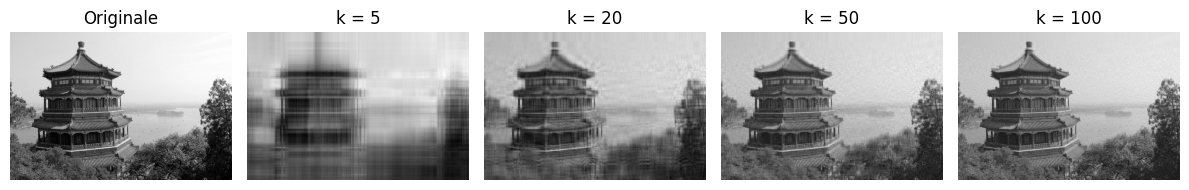

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.datasets import load_sample_image

# --- Fonction de compression SVD ---
def compress_svd(image, k):
    U, S, Vt = svd(image, full_matrices=False)
    return np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))

# --- Charger l'image de test ---
china = load_sample_image("china.jpg")
# Convertir en niveaux de gris pour simplifier la SVD
gray_china = np.mean(china, axis=2)

# --- Choisir des valeurs de k ---
ks = [5, 20, 50, 100]

# --- Affichage ---
plt.figure(figsize=(12, 6))

# Image originale
plt.subplot(1, len(ks)+1, 1)
plt.imshow(gray_china, cmap='gray')
plt.title("Originale")
plt.axis("off")

# Images compressées
for i, k in enumerate(ks, start=2):
    compressed = compress_svd(gray_china, k)
    plt.subplot(1, len(ks)+1, i)
    plt.imshow(compressed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()


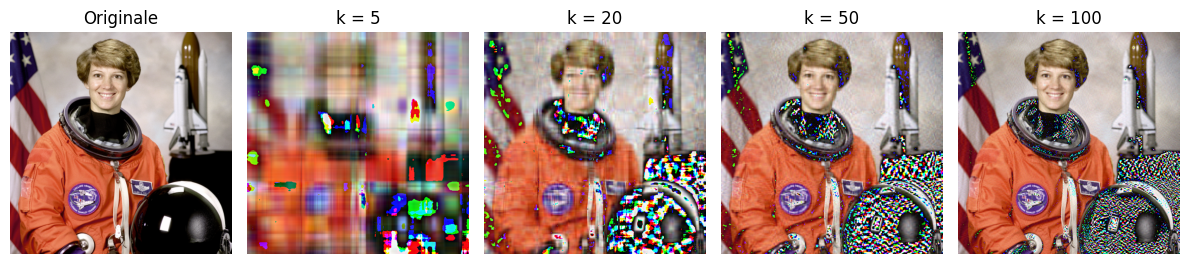

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.datasets import load_sample_image

# --- Fonction de compression SVD pour 1 canal ---
def compress_svd_channel(channel, k):
    U, S, Vt = svd(channel, full_matrices=False)
    return np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))

# --- Fonction pour compresser une image couleur ---
def compress_svd_color(image, k):
    # Séparer les 3 canaux (R, G, B)
    channels = []
    for i in range(3):
        compressed_channel = compress_svd_channel(image[:, :, i], k)
        channels.append(compressed_channel)
    # Recombiner en image couleur
    return np.stack(channels, axis=2).astype(np.uint8)

# --- Charger l'image de test (China) ---
china = data.astronaut()

# --- Choisir des valeurs de k ---
ks = [5, 20, 50, 100]

# --- Affichage ---
plt.figure(figsize=(12, 6))

# Image originale
plt.subplot(1, len(ks)+1, 1)
plt.imshow(china)
plt.title("Originale")
plt.axis("off")

# Images compressées
for i, k in enumerate(ks, start=2):
    compressed = compress_svd_color(china, k)
    plt.subplot(1, len(ks)+1, i)
    plt.imshow(compressed)
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()


#Image compression using PCA




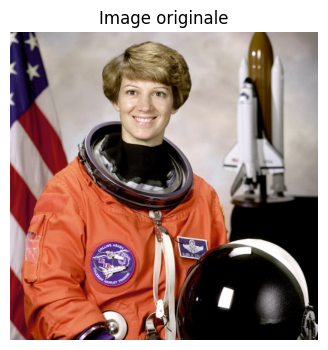

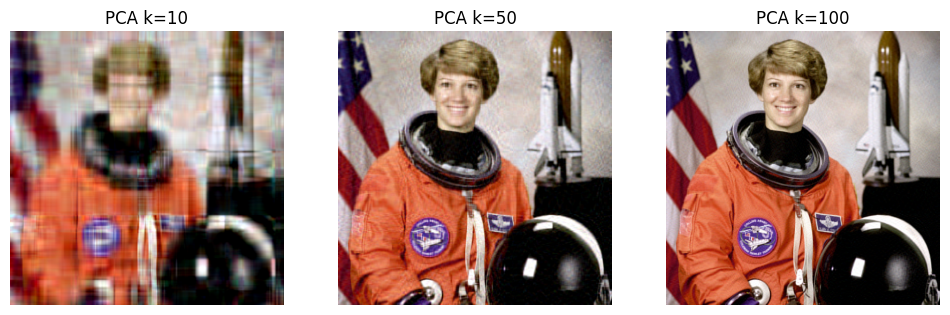

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage import data

# Charger une image exemple
image = data.astronaut()
plt.figure(figsize=(4,4))
plt.title("Image originale")
plt.imshow(image)
plt.axis("off")
plt.show()

def compress_pca(image, k):
    # On applique PCA séparément sur chaque canal de couleur
    compressed_channels = []
    for channel in range(3):  # R, G, B
        img_channel = image[:, :, channel]
        # Appliquer PCA
        pca = PCA(n_components=k)
        transformed = pca.fit_transform(img_channel)
        # Reconstruction
        reconstructed = pca.inverse_transform(transformed)
        compressed_channels.append(reconstructed)

    # Recomposer l'image couleur
    compressed_image = np.stack(compressed_channels, axis=2)
    return np.clip(compressed_image, 0, 255).astype(np.uint8)

# Compression avec différentes valeurs de k
ks = [10, 50, 100]

plt.figure(figsize=(12, 4))
for i, k in enumerate(ks):
    compressed_img = compress_pca(image, k)
    plt.subplot(1, len(ks), i+1)
    plt.imshow(compressed_img)
    plt.title(f"PCA k={k}")
    plt.axis("off")
plt.show()

#Image compression using auto-encoder

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


Epoch [1/10], Loss: 0.040180
Epoch [2/10], Loss: 0.015202
Epoch [3/10], Loss: 0.011464
Epoch [4/10], Loss: 0.009552
Epoch [5/10], Loss: 0.008534
Epoch [6/10], Loss: 0.007873
Epoch [7/10], Loss: 0.007407
Epoch [8/10], Loss: 0.007046
Epoch [9/10], Loss: 0.006746
Epoch [10/10], Loss: 0.006502


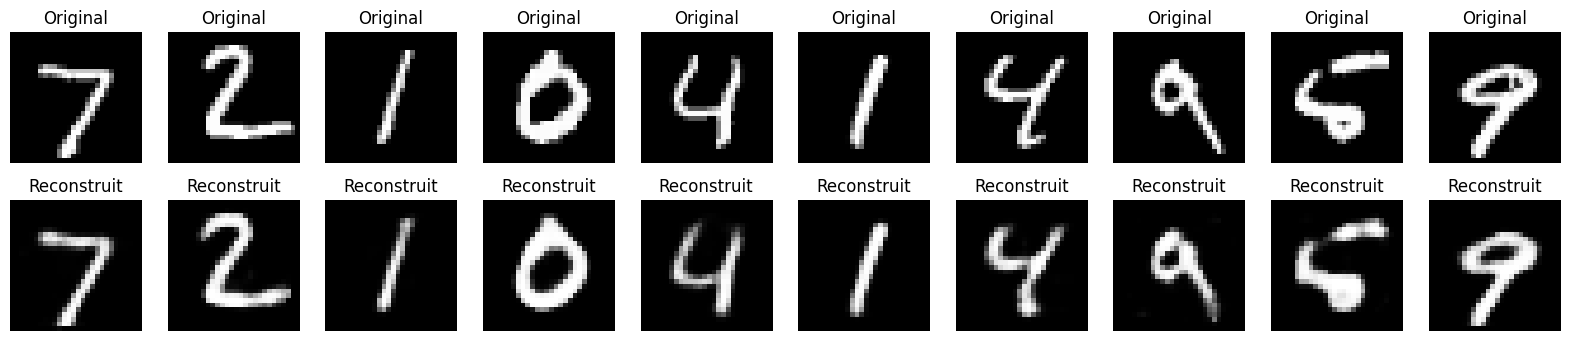

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =======================
# 1. Préparer les données
# =======================
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# =======================
# 2. Définir l’autoencodeur
# =======================
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(Autoencoder, self).__init__()
        # Encodeur
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        # Decodeur
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),  # sortie entre 0 et 1
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# =======================
# 3. Initialisation
# =======================
latent_dim = 32
model = Autoencoder(latent_dim=latent_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# =======================
# 4. Entraînement
# =======================
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        imgs, _ = batch
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

# =======================
# Test et visualisation
# =======================
model.eval()
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    outputs = model(imgs)

# Afficher les résultats
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Image originale
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(imgs[i][0].numpy(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(outputs[i][0].numpy(), cmap="gray")
    plt.title("Reconstruit")
    plt.axis("off")
plt.show()